## Prompt Chaining

Prompt Chaining is a technique in natural language processing where multiple prompts are sequenced to guide a model through a comples tasks or a reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the tasks into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherance, and control when working with large language models.

![Screenshot 2026-05-05 152801.png](<attachment:Screenshot 2026-05-05 152801.png>)
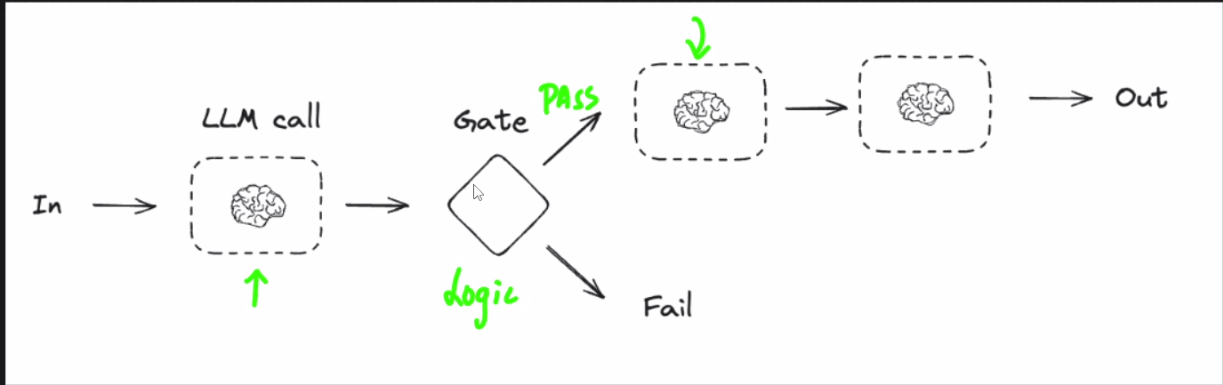

### How **Prompt Chaining** works with LangGraph

1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For e.g, if you want to generate a detailed report, you might split it into steps like 'gather data', 'analyze data' and 'write summary'

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text".

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the 'gather data' node flows into the 'analyze data' node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results. 

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ['NVIDIA_API_KEY'] = os.getenv('NVIDIA_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Prompt Chaining"

from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
  model="openai/gpt-oss-20b",
  api_key=os.getenv('NVIDIA_API_KEY'), 
  temperature=1,
  top_p=1,
  max_completion_tokens=4096,
)

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to a simple "Hello". Likely greet back. Could continue conversation. Maybe ask what they need help with. So respond friendly.', 'reasoning': 'We need to respond to a simple "Hello". Likely greet back. Could continue conversation. Maybe ask what they need help with. So respond friendly.', '_reasoning_api_fields': ['reasoning_content', 'reasoning']}, response_metadata={'role': 'assistant', 'content': 'Hello! 👋 How can I help you today?', 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [], 'reasoning': 'We need to respond to a simple "Hello". Likely greet back. Could continue conversation. Maybe ask what they need help with. So respond friendly.', 'reasoning_content': 'We need to respond to a simple "Hello". Likely greet back. Could continue conversation. Maybe ask what they need help with. So respond friendly.', 'token_usage': {'pro

In [2]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class State:
    topic: str
    story: Optional[str] = None        
    improved: Optional[str] = None     
    final_story: Optional[str] = None  

## Nodes
def generate_story(state: State):
    msg = llm.invoke(f"Write a one sentence story premise about {state.topic}")
    return {"story": msg.content}

def check_conflict(state:State):
    if "?" in state.story or "!" in state.story:
        return "FAIL"
    else:
        return "PASS"

def improved_story(state: State):
    msg = llm.invoke(f"Enhance this story with the vivid details : {state.story}")
    return {"improved": msg.content}

def polished_story(state: State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise: {state.improved}")
    return {"final_story": msg.content}

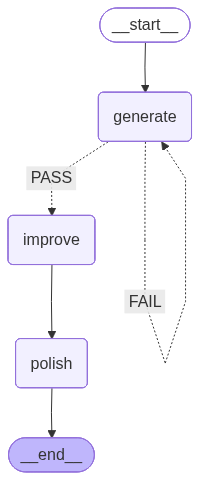

In [3]:
## Build the Graph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display 

builder = StateGraph(State)
memory = MemorySaver()

builder.add_node("generate", generate_story)
builder.add_node("improve", improved_story)
builder.add_node("polish", polished_story)

## Edges
builder.add_edge(START, "generate")
builder.add_conditional_edges("generate", check_conflict, {"PASS" : "improve", "FAIL" : "generate"})
builder.add_edge("improve", "polish")
builder.add_edge("polish", END)

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
## Run the Graph
config = {"configurable" : {"thread_id" : 1}}
state = {"topic" : "Black Hole"}
result = graph.invoke(state, config=config)
print("TOPIC: ", result['topic'])
print("Story: ", result['story'])
print(result['improved'])
print()
print("Final Story: ",result['final_story'])

TOPIC:  Black Hole
Story:  A lone astrophysicist slips past a black hole’s event horizon to discover a pocket universe that mirrors Earth, yet hides humanity’s ancient origins inside its very singularity.
**Dr. Eliana Kavanagh had never imagined that one of the darkest objects in the cosmos would turn out to be the lantern that would light her own past.**

The *Eclipse Reconnaissance Vessel* glided through the void, the faint flicker of its ion thrusters a lonely lantern in a sea of black. Outside, beyond the thin titanium hull, nothing but the understory of diffuse interstellar dust when the calm, mapless universe would let you believe it was empty. Inside, however, the chamber was a humming heart of human ingenuity: delicate arrays of quantum sensors, the fuzzy glow of a quantum entanglement drive, and on the holodisplay, the black slice of a million‐light-year spread, a target, a point that would swallow all knowing.

The target was *NGC 6048X*, a supermassive black hole that sat ne

### Benefits of Chaining with LangGraph
- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on the aspect at a time, reducing the risk of losing context in long inputs.
- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.
- Debugging: If something goes wrong, it's easier to pinpoint which step failed and adjust the prompt or logic accordingly
- Complex Reasoning: Chaining prompts allows the model to 'think' step-by-step, mimicking human problem-solving more effectively.